In [37]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import torch
from sklearn.metrics import f1_score, classification_report
import random
import pickle
import os
from collections import defaultdict
from catboost import CatBoostClassifier, Pool

EXP_NAME = 'exp_catboost_graph_based'

print("Loading precomputed splits...")
SPLITS_DIR = 'splits'
assert os.path.exists(SPLITS_DIR)

train_nodes = np.load(os.path.join(SPLITS_DIR, 'train_nodes.npy')).tolist()
val_nodes = np.load(os.path.join(SPLITS_DIR, 'val_nodes.npy')).tolist()
test_nodes = np.load(os.path.join(SPLITS_DIR, 'test_nodes.npy')).tolist()
unknown_nodes = np.load(os.path.join(SPLITS_DIR, 'unknown_nodes.npy')).tolist()
node_labels = np.load(os.path.join(SPLITS_DIR, 'node_labels_masked.npy'))

with open(os.path.join(SPLITS_DIR, 'labels.txt'), 'r') as f:
    labels = [line.strip() for line in f]

with open(os.path.join(SPLITS_DIR, 'metadata.pkl'), 'rb') as f:
    metadata = pickle.load(f)

max_node = metadata['max_node']
print(f"Labels: {labels}")
print(f"Train nodes: {len(train_nodes)}, Val nodes: {len(val_nodes)}, Test nodes: {len(test_nodes)}")

node_class = np.zeros((max_node + 1, len(labels)))
for n in range(max_node + 1):
    if node_labels[n] >= 0:
        node_class[n, node_labels[n]] = 1
    else:
        node_class[n, :] = np.ones(len(labels)) / len(labels)

data = pd.read_csv('CR_real_masks_more_labeled_veritices_agreed.csv')
data['node_id1'] -= 1
data['node_id2'] -= 1

device = torch.device("cuda:1")
print(f"Device: {device}")

random.seed(42)
np.random.seed(42)

unknown_nodes_shuffled = unknown_nodes.copy()
random.shuffle(unknown_nodes_shuffled)
NUM_UNKNOWN_FRACTION = 1.0
num_unknown_to_use = int(len(unknown_nodes_shuffled) * NUM_UNKNOWN_FRACTION)
unknown_nodes_subset = set(unknown_nodes_shuffled[:num_unknown_to_use])
print(f"Keeping {num_unknown_to_use} unknown nodes ({NUM_UNKNOWN_FRACTION*100:.0f}%), removing {len(unknown_nodes) - num_unknown_to_use}")

Loading precomputed splits...
Labels: ['Belarusians', 'Northen Russians', 'Southern Russians', 'Ukranians']
Train nodes: 2779, Val nodes: 927, Test nodes: 927
Device: cuda:1
Keeping 226254 unknown nodes (100%), removing 0


In [38]:
from torch_geometric.nn import Node2Vec
import networkx as nx

NODE2VEC_DIM = 32
NODE2VEC_WALK_LENGTH = 20
NODE2VEC_CONTEXT_SIZE = 10
NODE2VEC_WALKS_PER_NODE = 10
NODE2VEC_P = 1.0
NODE2VEC_Q = 1.0
NODE2VEC_EPOCHS = 50

graph_nodes = set(train_nodes + val_nodes + test_nodes) | unknown_nodes_subset
graph_edges_mask = (data['node_id1'].isin(graph_nodes) & data['node_id2'].isin(graph_nodes))
graph_edges = data[graph_edges_mask]

# Create node mapping for the graph
all_graph_nodes = sorted(graph_nodes)
node_to_idx = {n: i for i, n in enumerate(all_graph_nodes)}
idx_to_node = {i: n for n, i in node_to_idx.items()}

# Build edge_index for Node2Vec
src = [node_to_idx[n] for n in graph_edges['node_id1'].values]
dst = [node_to_idx[n] for n in graph_edges['node_id2'].values]
self_loops = list(range(len(all_graph_nodes)))
graph_edge_index = torch.tensor(
    [src + dst + self_loops, dst + src + self_loops],
    dtype=torch.long
)

print(f"Graph: {len(all_graph_nodes)} nodes, {graph_edge_index.shape[1]} edges")

# Train Node2Vec
node2vec_model = Node2Vec(
    graph_edge_index,
    embedding_dim=NODE2VEC_DIM,
    walk_length=NODE2VEC_WALK_LENGTH,
    context_size=NODE2VEC_CONTEXT_SIZE,
    walks_per_node=NODE2VEC_WALKS_PER_NODE,
    p=NODE2VEC_P,
    q=NODE2VEC_Q,
    num_negative_samples=1,
    sparse=True
).to(device)

node2vec_loader = node2vec_model.loader(batch_size=128, shuffle=True, num_workers=4)
node2vec_optimizer = torch.optim.SparseAdam(node2vec_model.parameters(), lr=0.01)

print("Training Node2Vec...")
node2vec_model.train()
for epoch in range(1, NODE2VEC_EPOCHS + 1):
    total_loss = 0
    for pos_rw, neg_rw in tqdm(node2vec_loader, desc=f'Node2Vec Epoch {epoch}'):
        node2vec_optimizer.zero_grad()
        loss = node2vec_model.loss(pos_rw.to(device), neg_rw.to(device))
        loss.backward()
        node2vec_optimizer.step()
        total_loss += loss.item()
    print(f"Node2Vec Epoch {epoch}: loss={total_loss/len(node2vec_loader):.4f}")

# Get embeddings for all graph nodes
node2vec_model.eval()
with torch.no_grad():
    graph_node_embeddings = node2vec_model.embedding.weight.cpu()

print(f"Node2Vec embeddings shape: {graph_node_embeddings.shape}")

# Create a lookup: original_node_id -> embedding
node2vec_embeddings = {}
for idx, node in idx_to_node.items():
    node2vec_embeddings[node] = graph_node_embeddings[idx].numpy()


Graph: 230887 nodes, 13836701 edges
Training Node2Vec...


Node2Vec Epoch 1: 100%|██████████| 1804/1804 [00:17<00:00, 105.33it/s]


Node2Vec Epoch 1: loss=1.7201


Node2Vec Epoch 2: 100%|██████████| 1804/1804 [00:16<00:00, 107.03it/s]


Node2Vec Epoch 2: loss=1.0905


...

Node2Vec Epoch 48: loss=1.0046


Node2Vec Epoch 49: 100%|██████████| 1804/1804 [00:16<00:00, 106.64it/s]


Node2Vec Epoch 49: loss=1.0044


Node2Vec Epoch 50: 100%|██████████| 1804/1804 [00:16<00:00, 106.53it/s]


Node2Vec Epoch 50: loss=1.0042
Node2Vec embeddings shape: torch.Size([230887, 32])


In [39]:
def compute_graph_based_features(sorted_nodes, subgraph_edges, node_class_input, num_classes):
    num_nodes = len(sorted_nodes)
    node_mapping = {node: i for i, node in enumerate(sorted_nodes)}
    node_class_subset = node_class_input[sorted_nodes]
    node_labels_arr = np.argmax(node_class_subset, axis=1)
    node_labels_arr[np.max(node_class_subset, axis=1) <= 0.5] = -1
    features = np.zeros((num_nodes, 5 * num_classes), dtype=np.float32)
    weights_per_node_class = defaultdict(list)
    edges = subgraph_edges[['node_id1', 'node_id2', 'ibd_sum']].values
    for n1, n2, w in edges:
        if n1 in node_mapping and n2 in node_mapping:
            i, j = node_mapping[n1], node_mapping[n2]
            c_j, c_i = node_labels_arr[j], node_labels_arr[i]
            if c_j >= 0:
                features[i, c_j] += 1
                features[i, num_classes + c_j] += w
                features[i, 3*num_classes + c_j] = max(features[i, 3*num_classes + c_j], w)
                features[i, 4*num_classes + c_j] += w
                weights_per_node_class[(i, c_j)].append(w)
            if c_i >= 0:
                features[j, c_i] += 1
                features[j, num_classes + c_i] += w
                features[j, 3*num_classes + c_i] = max(features[j, 3*num_classes + c_i], w)
                features[j, 4*num_classes + c_i] += w
                weights_per_node_class[(j, c_i)].append(w)
    count_mask = features[:, :num_classes] > 0
    features[:, num_classes:2*num_classes][count_mask] /= features[:, :num_classes][count_mask]
    for (i, c), weights in weights_per_node_class.items():
        if len(weights) > 1:
            features[i, 2*num_classes + c] = np.std(weights, dtype=np.float32)
    return torch.tensor(features, dtype=torch.float32)


In [40]:
NUM_CLASSES = len(labels)

# Define the set of nodes to include in the graph
# labeled nodes (train + val + test) + 5% of unknown nodes
graph_nodes_set = set(train_nodes + val_nodes + test_nodes) | unknown_nodes_subset
print(f"Graph nodes: {len(graph_nodes_set)} (labeled: {len(train_nodes) + len(val_nodes) + len(test_nodes)}, unknown kept: {len(unknown_nodes_subset)})")

# Create adjacency list with weights - only include edges between graph nodes
adj_list = defaultdict(list)  # node -> [(neighbor, weight), ...]
edges_included = 0
for _, row in tqdm(data.iterrows(), total=len(data), desc="Building adjacency"):
    n1, n2, w = int(row['node_id1']), int(row['node_id2']), row['ibd_sum']
    # Only include edge if BOTH nodes are in the graph
    if n1 in graph_nodes_set and n2 in graph_nodes_set:
        adj_list[n1].append((n2, w))
        adj_list[n2].append((n1, w))
        edges_included += 1

print(f"Adjacency list built for {len(adj_list)} nodes with {edges_included} edges")

Graph nodes: 230887 (labeled: 4633, unknown kept: 226254)


Building adjacency: 100%|██████████| 6802907/6802907 [04:38<00:00, 24410.53it/s]

Adjacency list built for 230887 nodes with 6802907 edges


In [41]:
# Define function to compute graph-based features for a single node
# This will be used to compute features for neighbors with the target node masked

def compute_node_graph_features(node, adj_list, node_labels, num_classes):
    """Compute graph-based features for a single node based on its neighbors."""
    features = np.zeros(5 * num_classes, dtype=np.float32)
    weights_per_class = defaultdict(list)
    
    for neighbor, weight in adj_list[node]:
        label = node_labels[neighbor]
        if label >= 0:  # Known label
            features[label] += 1  # Count
            features[num_classes + label] += weight  # Sum weight (will be averaged later)
            features[3 * num_classes + label] = max(features[3 * num_classes + label], weight)  # Max weight
            features[4 * num_classes + label] += weight  # Total weight
            weights_per_class[label].append(weight)
    
    # Average weight per class
    for c in range(num_classes):
        if features[c] > 0:
            features[num_classes + c] /= features[c]
    
    # Std of weights per class
    for c, weights in weights_per_class.items():
        if len(weights) > 1:
            features[2 * num_classes + c] = np.std(weights, dtype=np.float32)
    
    return features

print("Feature computation function defined.")


Feature computation function defined.


In [42]:
def compute_masked_features_for_node(target_node, adj_list, node_labels, base_features, 
                                       node2vec_embeddings, num_classes, known_nodes_set):
    """
    Compute features for a target node when it's masked.
    
    Features:
    1. Node's own graph-based features (with itself masked in computation)
    2. Percent of masked/unknown neighbors
    3. Average of all neighbors' base features
    4. Average of neighbors' Node2Vec embeddings
    """
    node2vec_dim = NODE2VEC_DIM
    graph_feat_dim = 5 * num_classes
    
    # 1. Compute node's own features with itself masked
    # This means neighbors won't "see" this node's label
    masked_node_labels = node_labels.copy()
    masked_node_labels[target_node] = -1  # Mask the target
    
    own_features = compute_node_graph_features(target_node, adj_list, masked_node_labels, num_classes)
    
    neighbors = adj_list[target_node]
    num_neighbors = len(neighbors)
    
    if num_neighbors == 0:
        # No neighbors - return zeros for aggregated features
        percent_masked = 0.0
        avg_neighbor_features = np.zeros(graph_feat_dim, dtype=np.float32)
        avg_neighbor_node2vec = np.zeros(node2vec_dim, dtype=np.float32)
    else:
        # 2. Percent of masked/unknown neighbors
        num_masked = sum(1 for n, _ in neighbors if n not in known_nodes_set)
        percent_masked = num_masked / num_neighbors
        
        # 3. Average of neighbors' base features
        neighbor_features = []
        for neighbor, weight in neighbors:
            if neighbor in base_features:
                neighbor_features.append(base_features[neighbor])
            else:
                neighbor_features.append(np.zeros(graph_feat_dim, dtype=np.float32))
        avg_neighbor_features = np.mean(neighbor_features, axis=0).astype(np.float32)
        
        # 4. Average of neighbors' Node2Vec embeddings
        neighbor_embeddings = []
        for neighbor, weight in neighbors:
            if neighbor in node2vec_embeddings:
                neighbor_embeddings.append(node2vec_embeddings[neighbor])
            else:
                neighbor_embeddings.append(np.zeros(node2vec_dim, dtype=np.float32))
        avg_neighbor_node2vec = np.mean(neighbor_embeddings, axis=0).astype(np.float32)
    
    # Concatenate all features
    # [own_features (20), percent_masked (1), avg_neighbor_features (20), avg_neighbor_node2vec (32)]
    final_features = np.concatenate([
        own_features,
        np.array([percent_masked], dtype=np.float32),
        avg_neighbor_features,
        avg_neighbor_node2vec
    ])
    
    return final_features

# Feature dimensions
FEATURE_DIM = 5 * NUM_CLASSES + 1 + 5 * NUM_CLASSES + NODE2VEC_DIM
print(f"Total feature dimension: {FEATURE_DIM}")


Total feature dimension: 73


In [43]:
# Create datasets for train, val, test
# For each split, mask nodes one by one and compute features

print("Creating datasets...")

# Known nodes set (for computing percent masked neighbors)
# For train: known = train_nodes (excluding current masked node)
# For val: known = train_nodes (validation node is masked)
# For test: known = train_nodes (test node is masked)

known_nodes_set = set(train_nodes)

def create_dataset_for_split(target_nodes, split_name):
    """Create feature matrix and labels for a split."""
    X = []
    y = []
    node_ids = []
    
    for node in tqdm(target_nodes, desc=f"Creating {split_name} dataset"):
        if node not in adj_list:
            continue  # Skip nodes without edges
        
        # For train nodes, we exclude the current node from known set
        if split_name == 'train':
            current_known = known_nodes_set - {node}
        else:
            # For val/test, the node is already not in train
            current_known = known_nodes_set
        
        features = compute_masked_features_for_node(
            node, adj_list, node_labels, base_features,
            node2vec_embeddings, NUM_CLASSES, current_known
        )
        
        X.append(features)
        y.append(node_labels[node])
        node_ids.append(node)
    
    return np.array(X), np.array(y), np.array(node_ids)

X_train, y_train, train_node_ids = create_dataset_for_split(train_nodes, 'train')
X_val, y_val, val_node_ids = create_dataset_for_split(val_nodes, 'val')
X_test, y_test, test_node_ids = create_dataset_for_split(test_nodes, 'test')

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")


Creating datasets...


Creating test dataset: 100%|██████████| 927/927 [03:00<00:00,  5.15it/s]

Train: (2779, 73), Val: (927, 73), Test: (927, 73)


In [44]:
# Save the dataset
DATASET_DIR = 'catboost_dataset'
os.makedirs(DATASET_DIR, exist_ok=True)

np.save(os.path.join(DATASET_DIR, 'X_train.npy'), X_train)
np.save(os.path.join(DATASET_DIR, 'y_train.npy'), y_train)
np.save(os.path.join(DATASET_DIR, 'train_node_ids.npy'), train_node_ids)

np.save(os.path.join(DATASET_DIR, 'X_val.npy'), X_val)
np.save(os.path.join(DATASET_DIR, 'y_val.npy'), y_val)
np.save(os.path.join(DATASET_DIR, 'val_node_ids.npy'), val_node_ids)

np.save(os.path.join(DATASET_DIR, 'X_test.npy'), X_test)
np.save(os.path.join(DATASET_DIR, 'y_test.npy'), y_test)
np.save(os.path.join(DATASET_DIR, 'test_node_ids.npy'), test_node_ids)

# Save feature names for interpretability
feature_names = []
for c in range(NUM_CLASSES):
    feature_names.append(f'count_class_{c}')
for c in range(NUM_CLASSES):
    feature_names.append(f'avg_weight_class_{c}')
for c in range(NUM_CLASSES):
    feature_names.append(f'std_weight_class_{c}')
for c in range(NUM_CLASSES):
    feature_names.append(f'max_weight_class_{c}')
for c in range(NUM_CLASSES):
    feature_names.append(f'total_weight_class_{c}')
feature_names.append('percent_masked_neighbors')
for c in range(NUM_CLASSES):
    feature_names.append(f'neigh_avg_count_class_{c}')
for c in range(NUM_CLASSES):
    feature_names.append(f'neigh_avg_weight_class_{c}')
for c in range(NUM_CLASSES):
    feature_names.append(f'neigh_std_weight_class_{c}')
for c in range(NUM_CLASSES):
    feature_names.append(f'neigh_max_weight_class_{c}')
for c in range(NUM_CLASSES):
    feature_names.append(f'neigh_total_weight_class_{c}')
for i in range(NODE2VEC_DIM):
    feature_names.append(f'neigh_node2vec_{i}')

with open(os.path.join(DATASET_DIR, 'feature_names.pkl'), 'wb') as f:
    pickle.dump(feature_names, f)

print(f"Dataset saved to {DATASET_DIR}/")


Dataset saved to catboost_dataset/


In [45]:
# Train basic CatBoost classifier
print("Training basic CatBoost classifier...")

# Class weights for imbalanced data
class_counts = np.bincount(y_train)
class_weights = {i: max(class_counts) / c for i, c in enumerate(class_counts)}
print(f"Class counts: {class_counts}")
print(f"Class weights: {class_weights}")

# Create pools
train_pool = Pool(X_train, y_train)
val_pool = Pool(X_val, y_val)

# Basic CatBoost model
model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.1,
    depth=6,
    l2_leaf_reg=3,
    loss_function='MultiClass',
    class_weights=class_weights,
    random_seed=42,
    verbose=100,
    early_stopping_rounds=50,
    task_type='GPU',
    devices='1'
)

model.fit(train_pool, eval_set=val_pool)

# Evaluate
y_pred_train = model.predict(X_train).flatten()
y_pred_val = model.predict(X_val).flatten()
y_pred_test = model.predict(X_test).flatten()

train_f1 = f1_score(y_train, y_pred_train, average='macro')
val_f1 = f1_score(y_val, y_pred_val, average='macro')

print(f"\nBasic CatBoost Results:")
print(f"Train F1 (macro): {train_f1:.4f}")
print(f"Val F1 (macro): {val_f1:.4f}")

Training basic CatBoost classifier...
Class counts: [408 954 934 483]
Class weights: {0: np.float64(2.338235294117647), 1: np.float64(1.0), 2: np.float64(1.0214132762312633), 3: np.float64(1.9751552795031055)}
0:	learn: 1.2818561	test: 1.2844828	best: 1.2844828 (0)	total: 8.82ms	remaining: 8.82s
100:	learn: 0.4542186	test: 0.7263532	best: 0.7258545 (97)	total: 771ms	remaining: 6.87s
bestTest = 0.7255837551
bestIteration = 123
Shrink model to first 124 iterations.

Basic CatBoost Results:
Train F1 (macro): 0.8664
Val F1 (macro): 0.7121


In [46]:
# Optuna hyperparameter tuning
import optuna
from optuna.samplers import TPESampler

def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 500, 2000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10, log=True),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 50),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
        'random_strength': trial.suggest_float('random_strength', 1e-3, 10, log=True),
        'grow_policy': trial.suggest_categorical('grow_policy', ['SymmetricTree', 'Depthwise', 'Lossguide']),
    }
    
    # Add grow_policy specific params
    if params['grow_policy'] == 'Lossguide':
        params['max_leaves'] = trial.suggest_int('max_leaves', 16, 64)
    
    model = CatBoostClassifier(
        **params,
        loss_function='MultiClass',
        class_weights=class_weights,
        random_seed=42,
        verbose=0,
        early_stopping_rounds=50,
        task_type='GPU',
        devices='1'
    )
    
    model.fit(train_pool, eval_set=val_pool)
    
    y_pred_val = model.predict(X_val).flatten()
    val_f1 = f1_score(y_val, y_pred_val, average='macro')
    
    return val_f1

# Run optimization
study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42),
    study_name='catboost_graph_based'
)

print("Starting Optuna optimization...")
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nBest trial:")
print(f"  Value (Val F1): {study.best_trial.value:.4f}")
print(f"  Params: {study.best_trial.params}")


[I 2025-12-05 14:30:59,042] A new study created in memory with name: catboost_graph_based


Starting Optuna optimization...


Best trial: 0. Best value: 0.691963:   2%|▏         | 1/50 [00:01<00:55,  1.14s/it]

[I 2025-12-05 14:31:00,183] Trial 0 finished with value: 0.6919628822025845 and parameters: {'iterations': 1062, 'learning_rate': 0.2536999076681772, 'depth': 9, 'l2_leaf_reg': 0.24810409748678125, 'min_data_in_leaf': 8, 'border_count': 66, 'bagging_temperature': 0.05808361216819946, 'random_strength': 2.9154431891537547, 'grow_policy': 'Depthwise'}. Best is trial 0 with value: 0.6919628822025845.


Best trial: 1. Best value: 0.705442:   4%|▍         | 2/50 [00:01<00:46,  1.04it/s]

...

[I 2025-12-05 14:33:32,697] Trial 47 finished with value: 0.7278996536564206 and parameters: {'iterations': 568, 'learning_rate': 0.03494082351601518, 'depth': 4, 'l2_leaf_reg': 0.5450050642868073, 'min_data_in_leaf': 18, 'border_count': 211, 'bagging_temperature': 0.4671815084931328, 'random_strength': 0.06408456144978503, 'grow_policy': 'Lossguide', 'max_leaves': 60}. Best is trial 31 with value: 0.730775360438791.


Best trial: 31. Best value: 0.730775:  98%|█████████▊| 49/50 [02:36<00:03,  3.18s/it]

[I 2025-12-05 14:33:36,016] Trial 48 finished with value: 0.7163051595126606 and parameters: {'iterations': 545, 'learning_rate': 0.03088143437100979, 'depth': 7, 'l2_leaf_reg': 0.5492472842105878, 'min_data_in_leaf': 18, 'border_count': 209, 'bagging_temperature': 0.9097907882703503, 'random_strength': 0.8050475691010206, 'grow_policy': 'Lossguide', 'max_leaves': 60}. Best is trial 31 with value: 0.730775360438791.


Best trial: 31. Best value: 0.730775: 100%|██████████| 50/50 [02:38<00:00,  3.18s/it]

[I 2025-12-05 14:33:38,025] Trial 49 finished with value: 0.7171391864381829 and parameters: {'iterations': 1378, 'learning_rate': 0.0405328173997653, 'depth': 5, 'l2_leaf_reg': 0.20382624260288568, 'min_data_in_leaf': 8, 'border_count': 172, 'bagging_temperature': 0.4702939237910042, 'random_strength': 0.03571411890789668, 'grow_policy': 'SymmetricTree'}. Best is trial 31 with value: 0.730775360438791.

Best trial:
  Value (Val F1): 0.7308
  Params: {'iterations': 608, 'learning_rate': 0.011938104158700528, 'depth': 4, 'l2_leaf_reg': 3.4905519918869805, 'min_data_in_leaf': 28, 'border_count': 235, 'bagging_temperature': 0.1479381792823054, 'random_strength': 0.11420582608742051, 'grow_policy': 'Lossguide', 'max_leaves': 45}


In [47]:
# Train best model and evaluate on test set
print("Training best model with optimal parameters...")

best_params = study.best_trial.params.copy()

best_model = CatBoostClassifier(
    **best_params,
    loss_function='MultiClass',
    class_weights=class_weights,
    random_seed=42,
    verbose=100,
    early_stopping_rounds=50,
    task_type='GPU',
    devices='1'
)

best_model.fit(train_pool, eval_set=val_pool)

# Final evaluation
y_pred_test_best = best_model.predict(X_test).flatten()

# Feature importance
feature_importance = best_model.get_feature_importance()
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("\nTop 20 Feature Importances:")
importance_df.head(20)


Training best model with optimal parameters...
0:	learn: 1.3728904	test: 1.3733887	best: 1.3733887 (0)	total: 6.4ms	remaining: 3.88s
100:	learn: 0.8192921	test: 0.8669910	best: 0.8669910 (100)	total: 621ms	remaining: 3.12s
200:	learn: 0.6663832	test: 0.7663378	best: 0.7663378 (200)	total: 1.22s	remaining: 2.48s
300:	learn: 0.5944262	test: 0.7361526	best: 0.7361526 (300)	total: 1.79s	remaining: 1.83s
400:	learn: 0.5517995	test: 0.7251920	best: 0.7251920 (400)	total: 2.32s	remaining: 1.2s
500:	learn: 0.5166322	test: 0.7201990	best: 0.7201990 (500)	total: 2.84s	remaining: 606ms
bestTest = 0.7193373074
bestIteration = 535
Shrink model to first 536 iterations.

Top 20 Feature Importances:


,feature,importance
38,neigh_total_weight_class_1,11.177665
68,neigh_node2vec_27,8.501615
39,neigh_total_weight_class_2,8.331420
18,total_weight_class_2,8.208819
37,neigh_total_weight_class_0,7.186872
16,total_weight_class_0,6.612983
40,neigh_total_weight_class_3,5.020048
29,neigh_std_weight_class_0,4.083149
17,total_weight_class_1,3.840395
24,neigh_avg_count_class_3,2.733605


In [48]:
# Generate submission
os.makedirs('submissions', exist_ok=True)

submission_df = pd.DataFrame({
    'node_id': test_node_ids,
    'predicted_label': [labels[p] for p in y_pred_test_best]
})

submission_path = f'submissions/{EXP_NAME}_{str(NUM_UNKNOWN_FRACTION)}.csv'
submission_df.to_csv(submission_path, index=False)
print(f"Submission saved to: {submission_path}")

# Score the submission
print(f"\nTo score: python score.py {submission_path}")


Submission saved to: submissions/exp_catboost_graph_based_1.0.csv

To score: python score.py submissions/exp_catboost_graph_based_1.0.csv


In [49]:
# Save the best model and study results
MODEL_DIR = 'models'
os.makedirs(MODEL_DIR, exist_ok=True)

best_model.save_model(os.path.join(MODEL_DIR, f'{EXP_NAME}_{str(NUM_UNKNOWN_FRACTION)}_best_model.cbm'))
print(f"Best model saved to: {MODEL_DIR}/{EXP_NAME}_{str(NUM_UNKNOWN_FRACTION)}_best_model.cbm")

# Save study results
study_results = {
    'best_params': study.best_trial.params,
    'best_value': study.best_trial.value,
    'n_trials': len(study.trials)
}
with open(os.path.join(MODEL_DIR, f'{EXP_NAME}_{str(NUM_UNKNOWN_FRACTION)}_study_results.pkl'), 'wb') as f:
    pickle.dump(study_results, f)

print(f"Study results saved to: {MODEL_DIR}/{EXP_NAME}_{str(NUM_UNKNOWN_FRACTION)}_study_results.pkl")


Best model saved to: models/exp_catboost_graph_based_1.0_best_model.cbm
Study results saved to: models/exp_catboost_graph_based_1.0_study_results.pkl


In [50]:
!python3 score.py submissions/{EXP_NAME}_{str(NUM_UNKNOWN_FRACTION)}.csv



SCORING: submissions/exp_catboost_graph_based_1.0.csv

Submission stats:
  Ground truth nodes: 927
  Submitted nodes:    927
  Matched nodes:      927

  MACRO F1 SCORE: 0.7157

Other metrics:
  Micro F1:    0.7443
  Weighted F1: 0.7463
  Accuracy:    0.7443


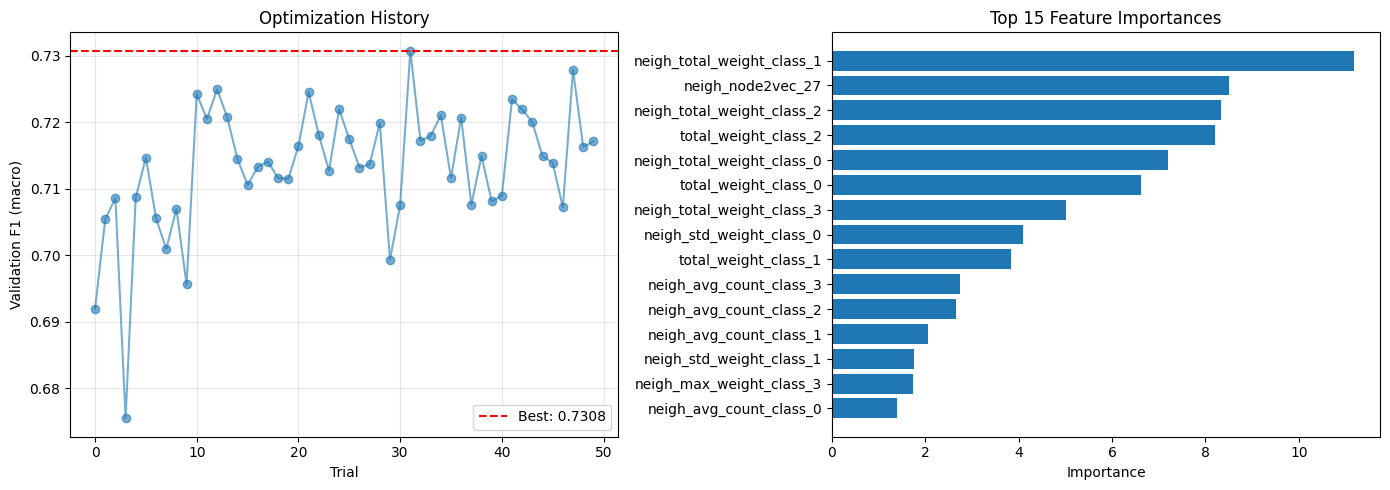

Results plot saved to: submissions/exp_catboost_graph_based_1.0_results.png


In [51]:
# Visualization of optimization history
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Optimization history
trials_df = study.trials_dataframe()
axes[0].plot(trials_df['number'], trials_df['value'], 'o-', alpha=0.6)
axes[0].axhline(y=study.best_trial.value, color='r', linestyle='--', label=f'Best: {study.best_trial.value:.4f}')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('Validation F1 (macro)')
axes[0].set_title('Optimization History')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Feature importance (top 15)
top_features = importance_df.head(15)
axes[1].barh(range(len(top_features)), top_features['importance'].values)
axes[1].set_yticks(range(len(top_features)))
axes[1].set_yticklabels(top_features['feature'].values)
axes[1].set_xlabel('Importance')
axes[1].set_title('Top 15 Feature Importances')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(f'submissions/{EXP_NAME}_{str(NUM_UNKNOWN_FRACTION)}_results.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Results plot saved to: submissions/{EXP_NAME}_{str(NUM_UNKNOWN_FRACTION)}_results.png")
